In [1]:
from google.colab import files
uploaded = files.upload()

Saving wine.csv to wine.csv


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [6]:
headernames =  ['Class', 'Alcohol', 'MalicAcid', 'Ash', 'AlcalinityOfAsh', 'Magnesium', 'TotalPhenols',
         'Flavanoids', 'NonflavanoidPhenols', 'Proanthocyanins', 'ColorIntensity',
         'Hue', 'OD280/OD315', 'Proline']

In [8]:
data = pd.read_csv("wine.csv", names=headernames)
data.shape

(178, 14)

In [12]:
data.head()

,Class,Alcohol,MalicAcid,Ash,AlcalinityOfAsh,Magnesium,TotalPhenols,Flavanoids,NonflavanoidPhenols,Proanthocyanins,ColorIntensity,Hue,OD280/OD315,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [13]:
unique = pd.unique(data['Class'])
print(unique)
n = len(unique)

print("No.of.unique values :", n)

[1 2 3]
No.of.unique values : 3


In [14]:
Y = data['Class']
print(Y)

0      1
1      1
2      1
3      1
4      1
      ..
173    3
174    3
175    3
176    3
177    3
Name: Class, Length: 178, dtype: int64


In [15]:
X = data.loc[:, data.columns != 'Class']
print(X)

     Alcohol  MalicAcid   Ash  AlcalinityOfAsh  Magnesium  TotalPhenols  \
0      14.23       1.71  2.43             15.6        127          2.80   
1      13.20       1.78  2.14             11.2        100          2.65   
2      13.16       2.36  2.67             18.6        101          2.80   
3      14.37       1.95  2.50             16.8        113          3.85   
4      13.24       2.59  2.87             21.0        118          2.80   
..       ...        ...   ...              ...        ...           ...   
173    13.71       5.65  2.45             20.5         95          1.68   
174    13.40       3.91  2.48             23.0        102          1.80   
175    13.27       4.28  2.26             20.0        120          1.59   
176    13.17       2.59  2.37             20.0        120          1.65   
177    14.13       4.10  2.74             24.5         96          2.05   

     Flavanoids  NonflavanoidPhenols  Proanthocyanins  ColorIntensity   Hue  \
0          3.06     

In [17]:
from sklearn.decomposition import PCA

X_norm = (X - X.min())/(X.max() - X.min())

pca = PCA(n_components=2) #2-dimensional PCA
transformed = pd.DataFrame(pca.fit_transform(X_norm))
print(transformed)

            0         1
0    0.706336  0.253193
1    0.484977  0.008823
2    0.521172  0.189187
3    0.821644  0.580906
4    0.202546  0.059467
..        ...       ...
173 -0.739510  0.471901
174 -0.581781  0.348366
175 -0.626313  0.546857
176 -0.572991  0.425516
177 -0.701764  0.513505

[178 rows x 2 columns]


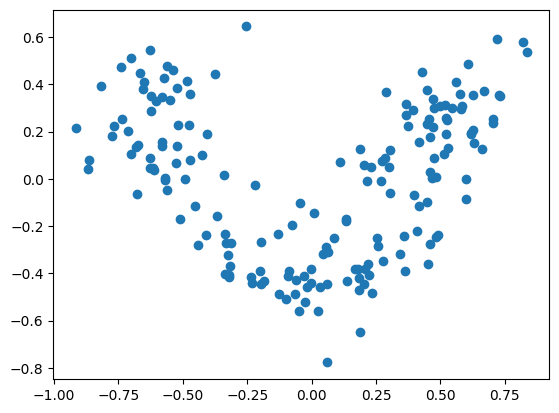

In [18]:
import matplotlib.pyplot as plt
x = transformed[0]
y = transformed[1]
plt.scatter(x,y)
plt.show()

Since 13 dimensions have been converted into 2 dimensions hance it is not accurate and is totally incorrect to come down to a conclusion in real life scenarios but still if you need to kind of visualize the dataset then you can use it.

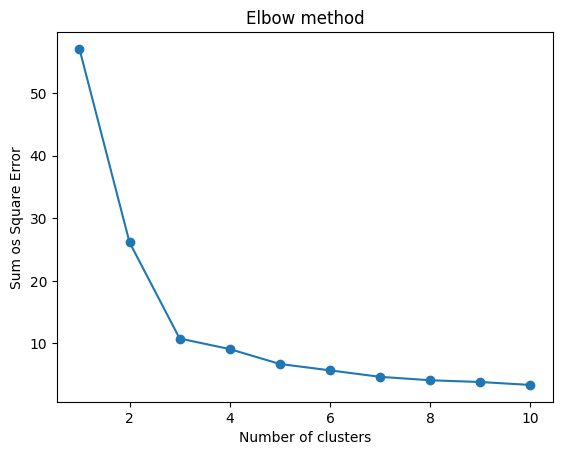

In [20]:
from sklearn.cluster import KMeans
data = list(zip(x, y))
inertias = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, n_init='auto')
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Sum os Square Error')
plt.show()

Since we can see the elbow shape at near around 3 so we will be taking the n_cluster = 3.

In [21]:
from sklearn.cluster import KMeans
data = list(zip(x, y))
kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(data)
c=kmeans.labels_
print(c)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 1 0 0 0 0 2 0 0 0 0 2 0 2
 2 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


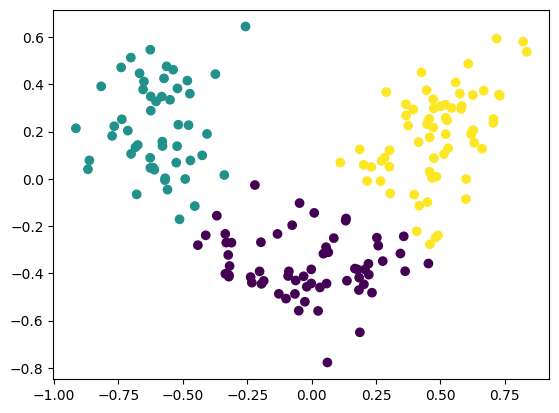

In [22]:
plt.scatter(x, y, c=c)
plt.show()

In [23]:
from sklearn import metrics
labels_true = Y
labels_pred = c
metrics.rand_score(Y, c)

0.9318225099980956

In [24]:
metrics.adjusted_rand_score(labels_true, labels_pred)

0.8470966807514034

In [25]:
metrics.adjusted_mutual_info_score(labels_true, labels_pred)

0.8329081448814434

In [26]:
metrics.homogeneity_score(labels_true, labels_pred)

0.8374696534711392

In [27]:
metrics.completeness_score(labels_true, labels_pred)

0.8318668502263008

In [28]:
metrics.v_measure_score(labels_true, labels_pred)

0.8346588494891205

In [29]:
metrics.fowlkes_mallows_score(labels_true, labels_pred)

0.8984161365917068